# 🔵 Program Kurva Lingkaran
> **Parametric Generation of Conic Curves**
> *Visualisasi dan Analisis Pengaruh Nilai $\Delta\theta$ terhadap Resolusi Kurva*

---

## 📌 Deskripsi
Program ini digunakan untuk membangkitkan **kurva lingkaran** menggunakan persamaan parametrik. Selain itu, program ini dirancang untuk membandingkan secara visual dan matematis pengaruh interval **$\Delta\theta$ (delta theta)** terhadap jumlah titik pembentuk dan kualitas *smoothness* (kehalusan) visualisasi kurva.

## 🎯 Tujuan Simulasi
1. Mengimplementasikan persamaan parametrik trigonometri untuk membentuk kurva lingkaran.
2. Menampilkan tabulasi titik-titik koordinat $(x, y)$ pembentuk kurva.
3. Menganalisis perbandingan resolusi grafis berdasarkan variasi nilai $\Delta\theta$.
4. Membuktikan secara komputasional bahwa semakin kecil nilai $\Delta\theta$, maka kerapatan titik semakin tinggi sehingga kurva terbentuk lebih halus.

---

## 📐 Dasar Teori
Lingkaran merupakan salah satu kurva irisan kerucut (*Conic Section*) tertutup yang memiliki nilai eksentrisitas sama dengan 0 ($e = 0$). Pada program komputasi ini, lingkaran dibangkitkan menggunakan **persamaan parametrik** dengan memanfaatkan fungsi trigonometri dasar:

$$x = xc + r \cdot \cos(\theta)$$
$$y = yc + r \cdot \sin(\theta)$$

**Tabel Parameter:**

| Simbol | Parameter | Keterangan |
| :---: | :--- | :--- |
| **$xc, yc$** | Titik Pusat | Koordinat pusat lingkaran pada sumbu Kartesian |
| **$r$** | Jari-jari (Radius) | Jarak dari pusat ke batas ujung lingkaran |
| **$\theta$** | Sudut Parameter | Parameter sudut pembentuk kurva (dalam radian) |
| **$\Delta\theta$** | *Step Size* | Interval perubahan parameter sudut $\theta$ |

---

## 🔍 Analisis Pengaruh $\Delta\theta$ (Resolusi)
Parameter $\theta$ dibangkitkan dari rentang interval **$0$ sampai $2\pi$** (membentuk 360 derajat atau satu putaran penuh tertutup). Nilai $\Delta\theta$ bertindak sebagai *step size* yang menentukan jarak antar titik komputasi.

* **Resolusi Rendah ($\Delta\theta$ Besar):**
  Contoh jika $\Delta\theta = 1.0$ radian, program hanya akan meng-*generate* sedikit titik (sekitar 7 titik). Akibatnya, grafik akan terlihat patah-patah seperti poligon kasar.
* **Resolusi Tinggi ($\Delta\theta$ Kecil):**
  Contoh jika $\Delta\theta = 0.1$ radian, program akan menghasilkan banyak titik (sekitar 63 titik rapat). Grafik lingkaran akan terlihat melengkung sempurna dan halus (*smooth*).

---

## ⚙️ Algoritma Program
1. **Inisialisasi Input:** Membaca nilai pusat $(xc, yc)$ serta jari-jari $(r)$.
2. **Konfigurasi Resolusi:** Menentukan nilai $\Delta\theta$ besar (untuk *drafting*) dan $\Delta\theta$ kecil (untuk rendering presisi).
3. **Pembangkitan Sudut:** Membuat deret *array* parameter $\theta$ dari $0$ hingga $2\pi$.
4. **Kalkulasi Koordinat:** Menghitung matriks titik $x$ dan $y$ secara simultan menggunakan persamaan parametrik trigonometri.
5. **Tabulasi Data:** Menampilkan hasil iterasi perhitungan titik ke dalam bentuk tabel.
6. **Visualisasi (Plotting):** Menggambar kurva menggunakan pustaka grafis dengan membandingkan dua resolusi secara berdampingan (*side-by-side*).

---

## 💡 Kesimpulan
Pendekatan **parametrik trigonometri** sangat efektif untuk membangkitkan kurva tertutup seperti lingkaran tanpa mengalami masalah fungsi ganda pada sumbu $Y$. Resolusi visual dari komputasi grafik ini sangat bergantung pada penentuan parameter **$\Delta\theta$**. Optimalisasi nilai *step size* ini penting untuk menyeimbangkan antara kualitas visual (kehalusan kurva) dan beban komputasi (jumlah iterasi memori).


  GENERATOR KURVA LINGKARAN PARAMETRIK

  --- PENENTUAN POSISI DAN UKURAN LINGKARAN ---

  --- PENENTUAN KUALITAS GAMBAR (RESOLUSI) ---
  [INFO] Lingkaran penuh adalah 360 derajat.
  Kita akan menggambar titik demi titik dari 0 sampai 360 derajat.


INFORMASI PARAMETER LINGKARAN - RESOLUSI RENDAH

TITIK PUSAT & JARI-JARI
-----------------------
Pusat (xc, yc) = (0.0, 0.0)
Jari-jari (r)  = 10.0

PERSAMAAN PARAMETRIK (θ)
------------------------
θ (theta) dihitung dalam radian.
x(θ) = 0.0 + 10.0·cos(θ)
y(θ) = 0.0 + 10.0·sin(θ)

RENTANG PARAMETER θ (Derajat)
-----------------------------
θ awal  = 0.0°
θ akhir = 360.0°
Loncatan θ = 50.00°

TAHAPAN PERHITUNGAN JUMLAH TITIK
--------------------------------
Jumlah Titik = ((θ akhir - θ awal) / Loncatan θ) + 1
             = ((360 - 0) / 50.0) + 1
             = (360 / 50.0) + 1
             = 9 titik (Termasuk titik akhir yang menutup lingkaran)

  TABEL PERHITUNGAN KOORDINAT LINGKARAN

  ----------------------------------------------------

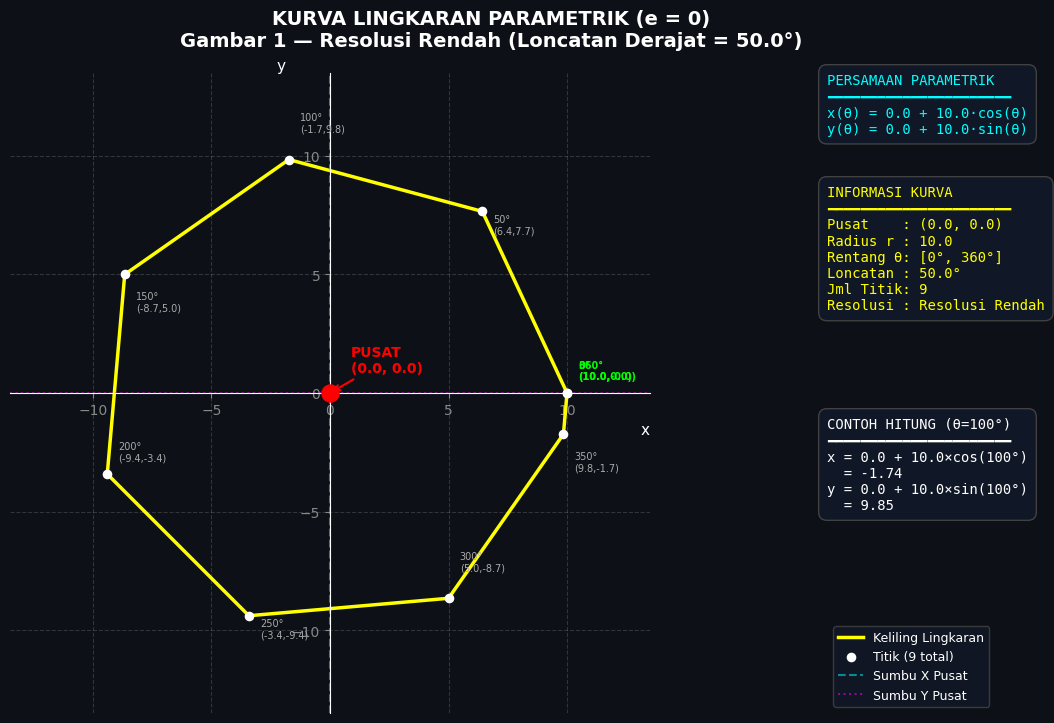

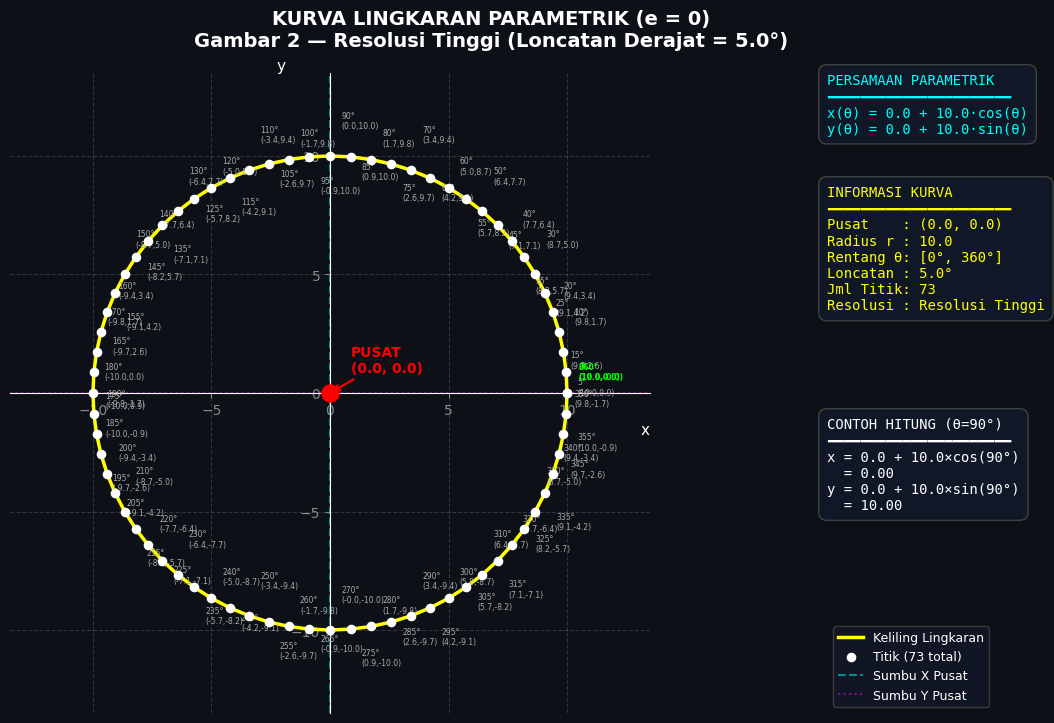

In [ ]:
"""
====================================================================
IMPLEMENTASI REPRESENTASI PARAMETRIK KURVA LINGKARAN
====================================================================
Mata Kuliah : Grafika Komputer - Semester 4
Kurva       : Lingkaran (Eksentrisitas e = 0)
====================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
import sys

plt.style.use('dark_background')

# ====================================================================
# BAGIAN 1 — INPUT PARAMETER (DENGAN BAHASA YANG LEBIH MUDAH)
# ====================================================================

def input_parameter():
    print()
    print("=" * 68)
    print("  GENERATOR KURVA LINGKARAN PARAMETRIK")
    print("=" * 68)
    print()
    
    print("  --- PENENTUAN POSISI DAN UKURAN LINGKARAN ---")
    xc = float(input("  1. Titik tengah lingkaran di sumbu X (Kiri/Kanan, contoh: 0) : "))
    yc = float(input("  2. Titik tengah lingkaran di sumbu Y (Bawah/Atas, contoh: 0) : "))
    r  = float(input("  3. Ukuran jari-jari lingkaran (Jarak ke pinggir, contoh: 5)  : "))
    print()
    
    print("  --- PENENTUAN KUALITAS GAMBAR (RESOLUSI) ---")
    print("  [INFO] Lingkaran penuh adalah 360 derajat.")
    print("  Kita akan menggambar titik demi titik dari 0 sampai 360 derajat.")
    print()
    
    step_rendah = float(input("  4. Loncatan derajat RESOLUSI RENDAH \n     (Ketik angka besar, misal 45 agar gambar patah-patah)     : "))
    step_tinggi = float(input("  5. Loncatan derajat RESOLUSI TINGGI \n     (Ketik angka kecil, misal 5 agar gambar mulus melingkar)  : "))
    print()

    return {
        "xc": xc,
        "yc": yc,
        "r": r,
        "theta_awal": 0.0,
        "theta_akhir": 360.0,
        "step_rendah": step_rendah,
        "step_tinggi": step_tinggi,
    }

# ====================================================================
# BAGIAN 2 — VALIDASI INPUT
# ====================================================================

def validasi_input(params):
    step_rendah = params["step_rendah"]
    step_tinggi = params["step_tinggi"]

    errors = []
    if params["r"] <= 0:
        errors.append("  [ERROR] Jari-jari harus lebih besar dari nol.")
    if step_rendah <= 0 or step_tinggi <= 0:
        errors.append("  [ERROR] Angka loncatan derajat harus positif.")
    if step_tinggi >= step_rendah:
        errors.append("  [ERROR] Loncatan resolusi tinggi harus LEBIH KECIL dari resolusi rendah.")
    
    if errors:
        print("\n" + "=" * 68 + "\n  VALIDASI GAGAL\n" + "=" * 68)
        for e in errors:
            print(e)
        sys.exit(1)

# ====================================================================
# BAGIAN 3 — TAMPILKAN INFORMASI PARAMETER
# ====================================================================

def tampilkan_informasi(params, theta_deg, label_resolusi):
    xc, yc, r = params["xc"], params["yc"], params["r"]
    step = theta_deg[1] - theta_deg[0] if len(theta_deg) > 1 else 0
    jumlah_titik = len(theta_deg)

    print("=" * 90)
    print(f"INFORMASI PARAMETER LINGKARAN - {label_resolusi}")
    print("=" * 90)

    print(f"""
TITIK PUSAT & JARI-JARI
-----------------------
Pusat (xc, yc) = ({xc}, {yc})
Jari-jari (r)  = {r}

PERSAMAAN PARAMETRIK (θ)
------------------------
θ (theta) dihitung dalam radian.
x(θ) = {xc} + {r}·cos(θ)
y(θ) = {yc} + {r}·sin(θ)

RENTANG PARAMETER θ (Derajat)
-----------------------------
θ awal  = {params["theta_awal"]}°
θ akhir = {params["theta_akhir"]}°
Loncatan θ = {step:.2f}°

TAHAPAN PERHITUNGAN JUMLAH TITIK
--------------------------------
Jumlah Titik = ((θ akhir - θ awal) / Loncatan θ) + 1
             = ((360 - 0) / {step}) + 1
             = (360 / {step}) + 1
             = {jumlah_titik} titik (Termasuk titik akhir yang menutup lingkaran)
""")

# ====================================================================
# BAGIAN 4 — PARAMETER & KOORDINAT
# ====================================================================

def buat_parameter_theta(theta_awal, theta_akhir, step):
    theta = np.arange(theta_awal, theta_akhir + 1e-9, step)
    # Memastikan titik terakhir tepat 360 derajat agar lingkaran menutup sempurna
    if not np.isclose(theta[-1], theta_akhir):
        theta = np.append(theta, theta_akhir)
    return theta

def hitung_koordinat(params, theta_deg):
    xc, yc, r = params["xc"], params["yc"], params["r"]
    theta_rad = np.radians(theta_deg)
    
    x = xc + r * np.cos(theta_rad)
    y = yc + r * np.sin(theta_rad)
    return x, y

# ====================================================================
# BAGIAN 5 — TABEL PERHITUNGAN
# ====================================================================

def tampilkan_tabel(params, theta_deg, x, y):
    xc, yc, r = params["xc"], params["yc"], params["r"]
    header = f"{'No':<5}{'θ (Deg)':<10}{'θ (Rad)':<10}{'Rumus X':<25}{'Hasil X':<12}{'Rumus Y':<25}{'Hasil Y':<12}"
    garis = "-" * len(header)

    print("  TABEL PERHITUNGAN KOORDINAT LINGKARAN\n")
    print("  " + garis + "\n  " + header + "\n  " + garis)

    for i in range(len(theta_deg)):
        th_deg = theta_deg[i]
        th_rad = np.radians(th_deg)
        
        rumus_x = f"{xc}+{r}×cos({th_deg:.0f}°)"
        rumus_y = f"{yc}+{r}×sin({th_deg:.0f}°)"
        
        print(f"  {i + 1:<5}{th_deg:<10.1f}{th_rad:<10.4f}{rumus_x:<25}{x[i]:<12.4f}{rumus_y:<25}{y[i]:<12.4f}")

    print("  " + garis + "\n")

# ====================================================================
# BAGIAN 6 — VISUALISASI MATPLOTLIB
# ====================================================================

def gambar_lingkaran(params, th_rdh, x_rdh, y_rdh, th_tg, x_tg, y_tg):
    xc, yc, r = params["xc"], params["yc"], params["r"]

    datasets = [
        {"th": th_rdh, "x": x_rdh, "y": y_rdh, "step": params["step_rendah"], "label": "Resolusi Rendah", "no_gbr": 1},
        {"th": th_tg, "x": x_tg, "y": y_tg, "step": params["step_tinggi"], "label": "Resolusi Tinggi", "no_gbr": 2},
    ]

    for ds in datasets:
        fig, ax = plt.subplots(figsize=(14, 8))
        fig.patch.set_facecolor('#0d1117')
        ax.set_facecolor('#0d1117')
        
        fig.suptitle(
            f"KURVA LINGKARAN PARAMETRIK (e = 0)\nGambar {ds['no_gbr']} — {ds['label']} (Loncatan Derajat = {ds['step']}°)", 
            fontsize=14, color='white', fontweight='bold', y=0.96
        )

        fig.subplots_adjust(left=0.05, right=0.72, top=0.88, bottom=0.08)

        # Plot Kurva
        ax.plot(ds["x"], ds["y"], color='yellow', linewidth=2.5, label='Keliling Lingkaran')
        ax.scatter(ds["x"], ds["y"], color='white', s=35, zorder=4, label=f'Titik ({len(ds["th"])} total)')

        # Label Koordinat Titik
        ukuran_font = 5.5 if len(ds["th"]) > 30 else 7.0
        for i in range(len(ds["th"])):
            offsets_y = [10, -16, 20, -26]
            offset_y = offsets_y[i % 4]
            
            weight = 'bold' if ds["th"][i] == 0 or ds["th"][i] == 360 else 'normal'
            warna = 'lime' if ds["th"][i] == 0 or ds["th"][i] == 360 else '#aaaaaa'
            
            ax.annotate(f'{ds["th"][i]:.0f}°\n({ds["x"][i]:.1f},{ds["y"][i]:.1f})', 
                        (ds["x"][i], ds["y"][i]), textcoords='offset points', xytext=(8, offset_y), 
                        fontsize=ukuran_font, color=warna, fontweight=weight)

        # Titik Pusat
        ax.scatter(xc, yc, color='red', s=150, zorder=10)
        ax.annotate(f'PUSAT\n({xc}, {yc})', xy=(xc, yc), xytext=(15, 15), 
                    textcoords='offset points', fontsize=10, color='red', fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

        # Garis Bantu Sumbu
        ax.axvline(xc, color='cyan', linestyle='--', linewidth=1.5, alpha=0.5, label='Sumbu X Pusat')
        ax.axhline(yc, color='magenta', linestyle=':', linewidth=1.5, alpha=0.5, label='Sumbu Y Pusat')

        # Panel Info Sidebar
        box_style = dict(facecolor='#111827', alpha=0.95, edgecolor='#444444', boxstyle='round,pad=0.6')
        
        panel_rumus = f"PERSAMAAN PARAMETRIK\n{'━'*22}\nx(θ) = {xc} + {r}·cos(θ)\ny(θ) = {yc} + {r}·sin(θ)"
        fig.text(0.74, 0.88, panel_rumus, fontsize=10, color='cyan', verticalalignment='top', fontfamily='monospace', bbox=box_style)

        panel_info = f"INFORMASI KURVA\n{'━'*22}\nPusat    : ({xc}, {yc})\nRadius r : {r}\nRentang θ: [0°, 360°]\nLoncatan : {ds['step']}°\nJml Titik: {len(ds['th'])}\nResolusi : {ds['label']}"
        fig.text(0.74, 0.74, panel_info, fontsize=10, color='yellow', verticalalignment='top', fontfamily='monospace', bbox=box_style)

        th_contoh = ds["th"][len(ds["th"])//4] 
        panel_contoh = f"CONTOH HITUNG (θ={th_contoh:.0f}°)\n{'━'*22}\nx = {xc} + {r}×cos({th_contoh:.0f}°)\n  = {xc + r*np.cos(np.radians(th_contoh)):.2f}\ny = {yc} + {r}×sin({th_contoh:.0f}°)\n  = {yc + r*np.sin(np.radians(th_contoh)):.2f}"
        fig.text(0.74, 0.45, panel_contoh, fontsize=10, color='white', verticalalignment='top', fontfamily='monospace', bbox=box_style)

        fig.legend(loc='lower left', bbox_to_anchor=(0.74, 0.08), fontsize=9, facecolor='#111827', edgecolor='#444444', labelcolor='white')

        ax.spines['left'].set_position(('data', xc))
        ax.spines['bottom'].set_position(('data', yc))
        ax.spines['right'].set_color('none')
        ax.spines['top'].set_color('none')
        ax.tick_params(colors='#888888')
        ax.grid(True, linestyle='--', alpha=0.15)
        
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlim(xc - 1.35*r, xc + 1.35*r)
        ax.set_ylim(yc - 1.35*r, yc + 1.35*r)

        ax.set_xlabel("x", color='white', fontsize=11, loc='right')
        ax.set_ylabel("y", color='white', fontsize=11, loc='top', rotation=0)

    plt.show()

# ====================================================================
# PROGRAM UTAMA
# ====================================================================

def main():
    params = input_parameter()
    validasi_input(params)

    # Bangkitkan nilai theta dalam derajat
    theta_rdh = buat_parameter_theta(params["theta_awal"], params["theta_akhir"], params["step_rendah"])
    theta_tg = buat_parameter_theta(params["theta_awal"], params["theta_akhir"], params["step_tinggi"])

    # Hitung koordinat
    x_rdh, y_rdh = hitung_koordinat(params, theta_rdh)
    x_tg, y_tg = hitung_koordinat(params, theta_tg)

    for label, th, x, y in [
        ("RESOLUSI RENDAH", theta_rdh, x_rdh, y_rdh),
        ("RESOLUSI TINGGI", theta_tg, x_tg, y_tg)
    ]:
        tampilkan_informasi(params, th, label)
        tampilkan_tabel(params, th, x, y)

    gambar_lingkaran(params, theta_rdh, x_rdh, y_rdh, theta_tg, x_tg, y_tg)

if __name__ == "__main__":
    main()